## MethodOfSimulatedMoments.jl and Bayesian optimization (BOSS.jl)

This notebook shows how one can estimate a model using [MethodOfSimulatedMoments.jl](https://github.com/JulienPascal/MethodOfSimulatedMoments.jl) and [BOSS.jl](https://github.com/soldasim/BOSS.jl), a package for **Bayesian optimization**.

"Bayesian optimization is a sequential model-based strategy for global optimization of black-box objective functions whose evaluations are costly. It is commonly used when a single observation requires an experiment, engineering computation, numerical simulation, or machine-learning run, and when derivatives are unavailable or unreliable. The objective need not have a closed-form expression. The method constructs a probabilistic model of the unknown function, often a Gaussian process (GP), and uses the resulting predictive distribution to choose the next evaluation point. This choice is made by optimizing a sampling criterion, also called an acquisition function. Common applications include hyperparameter optimization in machine learning, where each trial may require training and validating a model,and engineering design problems driven by expensive numerical simulations
"
**source:** https://en.wikipedia.org/wiki/Bayesian_optimization

See the documentation of BOSS.jl for more details: https://github.com/soldasim/BOSS.jl/.

In [1]:
using MethodOfSimulatedMoments
using BOSS
using Optim
using OrderedCollections
using Distributions
using Random
using Statistics
using LinearAlgebra
using Plots

In [2]:
using OptimizationPRIMA

In [3]:
Random.seed!(1234)  #for replicability reasons
T = 100000          #number of periods
P = 2               #number of independent variables
beta0 = rand(P)     #choose true coefficients by drawing from a uniform distribution on [0,1]
alpha0 = rand(1)[]  #intercept
theta0 = 0.0        #coefficient to create serial correlation in the error terms
println("True intercept = $(alpha0)")
println("True coefficient beta0 = $(beta0)")
println("Serial correlation coefficient theta0 = $(theta0)")

# Generation of error terms
# row = individual dimension
# column = time dimension 
U = zeros(T)
d = Normal()
U[1] = rand(d, 1)[] #first error term
# loop over time periods
for t = 2:T
    U[t] = rand(d, 1)[] + theta0*U[t-1]
end

# Let's simulate the independent variables x_t
x = zeros(T, P)

d = Uniform(0, 5)
for p = 1:P  
    x[:,p] = rand(d, T)
end

# Let's calculate the resulting y_t
y = zeros(T)

for t=1:T
    y[t] = alpha0 + x[t,1]*beta0[1] + x[t,2]*beta0[2] + U[t]
end

optionsSMM = MSMOptions(maxFuncEvals=1000, globalOptimizer = :dxnes, localOptimizer = :NelderMead)
myProblem = MSMProblem(options = optionsSMM);

# Priors
dictPriors = OrderedDict{String,Array{Float64,1}}()
dictPriors["alpha"] = [0.5, 0.001, 1.0]
dictPriors["beta1"] = [0.5, 0.001, 1.0]
dictPriors["beta2"] = [0.5, 0.001, 1.0]
set_priors!(myProblem, dictPriors)

# Empirical moments
dictEmpiricalMoments = OrderedDict{String,Array{Float64,1}}()
dictEmpiricalMoments = OrderedDict{String,Array{Float64,1}}()
dictEmpiricalMoments["mean"] = [mean(y)] #informative on the intercept
dictEmpiricalMoments["mean^2"] = [mean(y.^2)] #informative on the intercept
dictEmpiricalMoments["mean_x1y"] = [mean(x[:,1] .* y)] #informative on betas
dictEmpiricalMoments["mean_x2y"] = [mean(x[:,2] .* y)] #informative on betas
dictEmpiricalMoments["mean_x1y^2"] = [mean((x[:,1] .* y).^2)] #informative on betas
dictEmpiricalMoments["mean_x2y^2"] = [mean((x[:,2] .* y).^2)] #informative on betas
set_empirical_moments!(myProblem, dictEmpiricalMoments)

W = Matrix(1.0 .* I(length(dictEmpiricalMoments)))#initialization
#Special case: diagonal matrix (you may choose something else)
for (indexMoment, k) in enumerate(keys(myProblem.empiricalMoments))
    W[indexMoment,indexMoment] = 1.0/(myProblem.empiricalMoments[k][1])^2
end
set_weight_matrix!(myProblem, W)

# x[1] corresponds to the intercept, x[2] corresponds to beta1, x[3] corresponds to beta2
function functionLinearModel(x; uniform_draws::Array{Float64,1}, simX::Array{Float64,2}, nbDraws::Int64 = length(uniform_draws), burnInPerc::Int64 = 0)
    T = nbDraws
    P = 2       #number of independent variables

    alpha = x[1]
    beta = x[2:end]
    theta = 0.0     #coefficient to create serial correlation in the error terms

    # Creation of error terms
    # row = individual dimension
    # column = time dimension
    U = zeros(T)
    d = Normal()
    # Inverse cdf (i.e. quantile)
    gaussian_draws = quantile.(d, uniform_draws)
    U[1] = gaussian_draws[1] #first error term

    # loop over time periods
    for t = 2:T
        U[t] = gaussian_draws[t] + theta*U[t-1]
    end

    # Let's calculate the resulting y_t
    y = zeros(T)

    for t=1:T
        y[t] = alpha + simX[t,1]*beta[1] + simX[t,2]*beta[2] + U[t]
    end

    # Get rid of the burn-in phase:
    #------------------------------
    startT = max(1, floor(Int, nbDraws * burnInPerc / 100))

    # Moments:
    #---------
    output = OrderedDict{String,Float64}()
    output["mean"] = mean(y[startT:nbDraws])
    output["mean^2"] = mean(y[startT:nbDraws].^2)
    output["mean_x1y"] = mean(simX[startT:nbDraws,1] .* y[startT:nbDraws])
    output["mean_x2y"] = mean(simX[startT:nbDraws,2] .* y[startT:nbDraws])
    output["mean_x1y^2"] = mean((simX[startT:nbDraws,1] .* y[startT:nbDraws]).^2)
    output["mean_x2y^2"] = mean((simX[startT:nbDraws,2] .* y[startT:nbDraws]).^2)

    return output
end

# Let's freeze the randomness during the minimization
d_Uni = Uniform(0,1)
nbDraws = T #number of draws in the simulated data
uniform_draws = rand(d_Uni, nbDraws)
simX = zeros(length(uniform_draws), 2)
d = Uniform(0, 5)
for p = 1:2
  simX[:,p] = rand(d, length(uniform_draws))
end

set_simulate_empirical_moments!(myProblem, x -> functionLinearModel(x, uniform_draws = uniform_draws, simX = simX))
construct_objective_function!(myProblem)

True intercept = 0.21858665481883066
True coefficient beta0 = [0.32597672886359486, 0.5490511363155669]
Serial correlation coefficient theta0 = 0.0


(::MethodOfSimulatedMoments.var"#objective_function_MSM#construct_objective_function!##0"{MSMProblem}) (generic function with 1 method)

### Objective function and initial design

BOSS.jl **maximizes** a `fitness` of the output of a function `f(x)`, which returns a vector. Here:

* `f` is the logarithm of the MSM objective function. The objective function spans several orders of magnitude, and its logarithm is much easier to approximate with a Gaussian process (the objective function is > 0);
* the fitness is `-f`, so that maximizing the fitness minimizes the objective function;
* the domain is the box defined by the bounds of the priors.

BOSS.jl needs some initial data: the objective function is first evaluated at `nInitial` points of a Sobol sequence. Points are stored as the **columns** of a matrix.

In [4]:
lower_bound = create_lower_bound(myProblem)
upper_bound = create_upper_bound(myProblem)
nbParams = length(dictPriors)

# BOSS.jl expects a function returning a vector
log_objective(θ) = [log(myProblem.objective_function(collect(θ)))]

# Initial design: one point per column
nInitial = 20
X0 = permutedims(MethodOfSimulatedMoments.sobol_sampling(lower_bound, upper_bound, nInitial))
Y0 = reduce(hcat, log_objective.(eachcol(X0)))
println("Initial design: $(nInitial) points, best objective function = $(round(exp(minimum(Y0)), sigdigits = 3))")

Initial design: 20 points, best objective function = 0.0223


### Surrogate model and acquisition function

The surrogate model is a Gaussian process with a [Matérn 3/2 kernel](https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function). Its hyperparameters **are estimated at each iteration**, and BOSS.jl requires a prior for each of them:

* the **length scales** (one per parameter of the model): the distance over which the objective function varies. Prior: half-normal, with a scale of one third of the range of the parameter;
* the **amplitude**: the size of the variations of log(objective function). Prior: half-normal, scaled by the standard deviation of the initial values;
* the **noise**: the simulation draws are frozen, so the objective function is deterministic, and the prior keeps the noise small.

The mean of the Gaussian process is the mean of the initial values. The next point to evaluate maximizes the **expected improvement** over the best value found so far.

See: https://soldasim.github.io/BOSS.jl/dev/example/.

In [5]:
model = GaussianProcess(;
    mean = [mean(Y0)],
    kernel = BOSS.Matern32Kernel(),
    lengthscale_priors = [product_distribution([truncated(Normal(0., (upper_bound[i] - lower_bound[i])/3); lower = 0.) for i in 1:nbParams])],
    amplitude_priors = [truncated(Normal(0., 3*std(Y0)); lower = 0.)],
    noise_std_priors = [truncated(Normal(0., 0.01); lower = 0.)],
)

bossProblem = BossProblem(;
    f = log_objective,
    domain = Domain(; bounds = (lower_bound, upper_bound)),
    acquisition = ExpectedImprovement(; fitness = LinFitness([-1.0])), #maximize -log(objective function)
    model = model,
    data = ExperimentData(X0, Y0),
);

### Optimization

Each iteration of `bo!`:

1. estimates the hyperparameters of the Gaussian process (`model_fitter`);
2. maximizes the acquisition function to find the next point (`acq_maximizer`);
3. evaluates the objective function at this point, and adds it to the data.

Steps 1 and 2 are optimization problems themselves. Here, they are solved by random search: draw many candidates, and keep the best one. They do not evaluate the objective function: their cost is negligible when the objective function is expensive (here, it is cheap, and they dominate the running time).

BOSS.jl can also solve steps 1 and 2 with the algorithms of Optimization.jl (`OptimizationMAP`, `OptimizationAM`), as in the [example of BOSS.jl](https://github.com/soldasim/BOSS.jl/blob/master/examples/example.jl), which uses OptimizationPRIMA.jl. However, when I tried, the algorithms of PRIMA.jl throw a `StackOverflowError`. So here the notebook is using random search for step 1 and 2.

With `live = true`, the state of the optimization is plotted after each iteration.

In [6]:
# Live plot: the state of the optimization, redrawn after each iteration
#-----------------------------------------------------------------------
# BOSS.jl calls the callback given to BossOptions before the first iteration (first = true), and
# after each iteration. BOSS.jl's own PlotCallback only handles one parameter. With several
# parameters, the model cannot be plotted as a whole: this callback plots one-dimensional slices
# through the point chosen at this iteration (the other parameters are held at their values at this point).
mutable struct LivePlotCallback <: BossCallback
    prev_state::Union{Nothing, BossProblem}   #state before the iteration (model and acquisition used to choose the point)
    paramNames::Vector{String}
    nInitial::Int
    points::Int
    show_true::Bool
end
LivePlotCallback(; paramNames, nInitial, points = 30, show_true = true) = LivePlotCallback(nothing, paramNames, nInitial, points, show_true)

function (cb::LivePlotCallback)(problem::BossProblem; first, kwargs...)
    if first == false
        # The plot draws random numbers (expected improvement): the generator is restored afterwards,
        # so that the optimization is the same with and without the live plot
        rng = copy(Random.default_rng())
        show_live(plot_state(cb, cb.prev_state, problem))
        copy!(Random.default_rng(), rng)
    end
    cb.prev_state = deepcopy(problem)
end

function plot_state(cb::LivePlotCallback, previous::BossProblem, problem::BossProblem)

    colorInitial = "#a8a7a2"; colorAdded = "#2a78d6"; colorBest = "#eb6834"; colorAcquisition = "#104281"

    lb, ub = problem.domain.bounds
    x_new = problem.data.X[:, end]              #point chosen at this iteration
    objectiveValues = exp.(vec(problem.data.Y))
    n = length(objectiveValues)
    added = (cb.nInitial + 1):n

    # (1) History
    p_history = scatter(1:cb.nInitial, objectiveValues[1:cb.nInitial], color = colorInitial, markersize = 4,
                        markerstrokewidth = 0, label = "initial design")
    scatter!(p_history, added, objectiveValues[added], color = colorAdded, markersize = 4, markerstrokewidth = 0,
             label = "Bayesian optimization")
    plot!(p_history, 1:n, accumulate(min, objectiveValues), seriestype = :steppost, color = colorBest, linewidth = 2,
          label = "best so far")
    plot!(p_history, yscale = :log10, xlabel = "evaluation", ylabel = "objective function (log scale)",
          title = "iteration $(n - cb.nInitial): best objective function so far = $(round(minimum(objectiveValues), sigdigits = 3))",
          titlefontsize = 11, legend = :outerright, legendfontsize = 8, gridalpha = 0.3, left_margin = 6Plots.mm)

    # (2) Model and (3) acquisition function, before this iteration, along each parameter
    posterior = model_posterior_slice(previous, 1)
    acquisition = construct_acquisition(previous, BossOptions(; info = false))
    p_models = []
    p_acquisitions = []
    for i in eachindex(cb.paramNames)
        grid = range(lb[i], ub[i], length = cb.points)
        slice = [setindex!(copy(x_new), v, i) for v in grid]    #x_new, with parameter i replaced by v

        p = plot(grid, [mean(posterior, x) for x in slice], ribbon = [std(posterior, x) for x in slice],
                 color = colorAdded, fillalpha = 0.25, linewidth = 2, label = "model")
        if cb.show_true == true
            plot!(p, grid, [problem.f(x)[1] for x in slice], color = :black, linestyle = :dash, label = "objective function")
        end
        vline!(p, [x_new[i]], color = colorBest, linewidth = 1.5, label = "chosen point")
        plot!(p, ylabel = i == 1 ? "log(objective function)" : "", legend = i == 1 ? :topright : false,
              legendfontsize = 7, gridalpha = 0.3, left_margin = 6Plots.mm)
        push!(p_models, p)

        p = plot(grid, [acquisition(x) for x in slice], color = colorAcquisition, linewidth = 2, legend = false)
        vline!(p, [x_new[i]], color = colorBest, linewidth = 1.5)
        plot!(p, xlabel = cb.paramNames[i], ylabel = i == 1 ? "expected improvement" : "", gridalpha = 0.3,
              left_margin = 6Plots.mm, bottom_margin = 4Plots.mm)
        push!(p_acquisitions, p)
    end
    p_slices = plot(p_models..., p_acquisitions..., layout = (2, length(cb.paramNames)))

    return plot(p_history, p_slices, layout = Plots.grid(2, 1, heights = [0.35, 0.65]), size = (1000, 800))

end

# Display the figure. In Jupyter, it replaces the previous one (clear_output(true) waits for the
# new figure before clearing: no flicker)
function show_live(fig)
    if isdefined(Main, :IJulia) && Main.IJulia.inited
        Main.IJulia.clear_output(true)
    end
    display(fig)
end

show_live (generic function with 1 method)

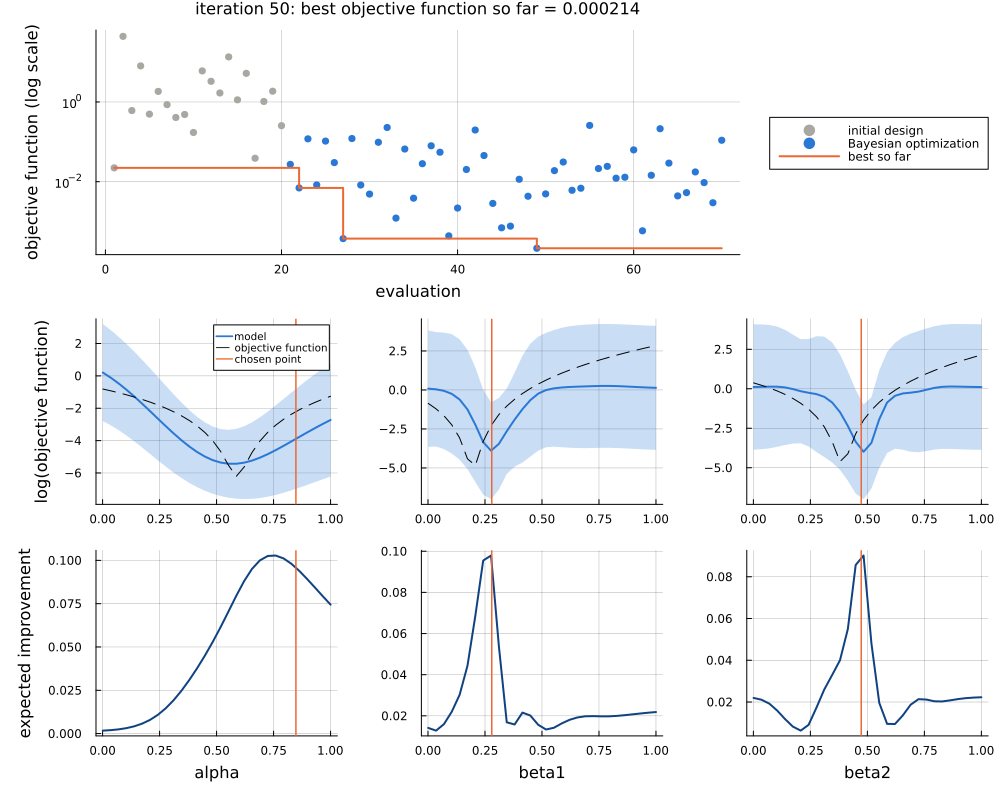

 29.814625 seconds (46.44 M allocations: 66.135 GiB, 21.67% gc time, 27.02% compilation time: 19% of which was recompilation)


In [7]:
# 1. Hyperparameters of the Gaussian process: maximum a posteriori, among `samples` draws from their priors
model_fitter = SamplingMAP(; samples = 500, parallel = false)

# 2. Maximization of the acquisition function: best of `samples` uniform draws within the bounds
acq_maximizer = SamplingAM(; x_prior = product_distribution(Uniform.(lower_bound, upper_bound)), samples = 2000, parallel = false)

# Without the live plot: display the progress every `every` iterations
struct ProgressCallback <: BossCallback
    every::Int
end
function (cb::ProgressCallback)(problem::BossProblem; first, kwargs...)
    iteration = size(problem.data.X, 2) - nInitial
    if first == false && iteration % cb.every == 0
        println("iteration $(iteration): best objective function so far = $(round(exp(minimum(problem.data.Y)), sigdigits = 3))")
    end
end

live = true         #plot the state of the optimization after each iteration (see LivePlotCallback above)
nbIterations = 50   #number of new evaluations of the objective function
callback = live ? LivePlotCallback(paramNames = collect(keys(dictPriors)), nInitial = nInitial) : ProgressCallback(10)
Random.seed!(1234)
@time bo!(bossProblem; model_fitter = model_fitter, acq_maximizer = acq_maximizer, term_cond = IterLimit(nbIterations),
          options = BossOptions(; info = false, callback = callback));

In [8]:
# Best point evaluated (BOSS.jl stores log(objective function))
best_x, best_y = result(bossProblem)

println("Number of evaluations of the objective function = $(size(bossProblem.data.X, 2))")
println("Minimum objective function = $(exp(best_y[1])) \n")
println("Estimated value for alpha = $(best_x[1]). True value for alpha = $(alpha0[1]) \n")
println("Estimated value for beta1 = $(best_x[2]). True value for beta1 = $(beta0[1]) \n")
println("Estimated value for beta2 = $(best_x[3]). True value for beta2 = $(beta0[2]) \n")

Number of evaluations of the objective function = 70
Minimum objective function = 0.0002144657724787478 

Estimated value for alpha = 0.217735744289183. True value for alpha = 0.21858665481883066 

Estimated value for beta1 = 0.3055111525915211. True value for beta1 = 0.32597672886359486 

Estimated value for beta2 = 0.5696079989985108. True value for beta2 = 0.5490511363155669 



Minimum objective function = 0.0002144657724787478 

Estimated value for alpha = 0.217735744289183. True value for alpha = 0.21858665481883066 

Estimated value for beta1 = 0.3055111525915211. True value for beta1 = 0.32597672886359486 

Estimated value for beta2 = 0.5696079989985108. True value for beta2 = 0.5490511363155669 



### Local refinement

The best point is used as the starting value of a local minimization (`msm_localmin`, with the local optimizer of `MSMOptions`).

In [9]:
@time localResults = msm_localmin(myProblem, best_x, verbose = false)
minimizer = Optim.minimizer(localResults)

println("Minimum objective function = $(Optim.minimum(localResults)) \n")
println("Estimated value for alpha = $(minimizer[1]). True value for alpha = $(alpha0[1]) \n")
println("Estimated value for beta1 = $(minimizer[2]). True value for beta1 = $(beta0[1]) \n")
println("Estimated value for beta2 = $(minimizer[3]). True value for beta2 = $(beta0[2]) \n")

  1.750486 seconds (12.56 M allocations: 1.857 GiB, 13.75% gc time, 80.81% compilation time)
Minimum objective function = 1.8040610202692818e-6 

Estimated value for alpha = 0.23986265503110044. True value for alpha = 0.21858665481883066 

Estimated value for beta1 = 0.31617688556398105. True value for beta1 = 0.32597672886359486 

Estimated value for beta2 = 0.5513078893732357. True value for beta2 = 0.5490511363155669 




Estimated value for alpha = 0.23986265503110044. True value for alpha = 0.21858665481883066 

Estimated value for beta1 = 0.31617688556398105. True value for beta1 = 0.32597672886359486 

Estimated value for beta2 = 0.5513078893732357. True value for beta2 = 0.5490511363155669 



### History of the optimization

The objective function at each evaluated point, in the order of evaluation (log scale). The initial design (gray) spreads over the parameter space. The points chosen by BOSS.jl (blue) alternate between low values (where the Gaussian process predicts a minimum) and high values (where it is uncertain).

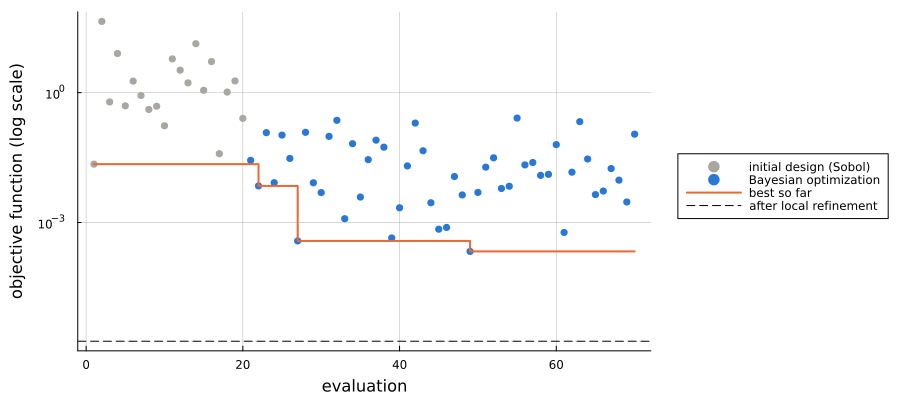

In [10]:
objectiveValues = exp.(vec(bossProblem.data.Y))
added = (nInitial + 1):length(objectiveValues)

scatter(1:nInitial, objectiveValues[1:nInitial], color = "#a8a7a2", markersize = 4, markerstrokewidth = 0,
        label = "initial design (Sobol)")
scatter!(added, objectiveValues[added], color = "#2a78d6", markersize = 4, markerstrokewidth = 0,
         label = "Bayesian optimization")
plot!(1:length(objectiveValues), accumulate(min, objectiveValues), seriestype = :steppost, color = "#eb6834",
      linewidth = 2, label = "best so far")
hline!([Optim.minimum(localResults)], color = :black, linestyle = :dash, linewidth = 1, label = "after local refinement")
plot!(yscale = :log10, xlabel = "evaluation", ylabel = "objective function (log scale)", legend = :outerright,
      gridalpha = 0.3, size = (900, 400), left_margin = 5Plots.mm, bottom_margin = 4Plots.mm)

In [11]:
versioninfo()

Julia Version 1.13.1
Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)


Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)
